# Regression Preparation

In [668]:
import os
import pandas as pd
import numpy as np

os.chdir('/Users/janlinzner/Projects/Master-Thesis-Spatial-Proximity-Venture-Capital')

In [669]:
data = pd.read_csv('data/sets-for-r/companies_seed.csv')

In [670]:
data

,Company ID,Organization Name,Organization Name URL,Description,Industry Groups,Headquarters Location,Headquarters Country,Latitude,Longitude,Founded Date,...,Latvia,Lithuania,Norway,Poland,Portugal,Slovakia (Slovak Republic),Spain,Switzerland,The Netherlands,United Kingdom
0,948,Safetica Technologies,https://www.crunchbase.com/organization/safeti...,Safetica is a data security software product t...,"Information Technology,Privacy and Security,So...","Prague, Hlavni mesto Praha, Czech Republic",Czech Republic,50.059629,14.446459,2007-01-01,...,False,False,False,False,False,False,False,False,False,False
1,9531,Process Relations,https://www.crunchbase.com/organization/proces...,Process Relations is a software vendor and con...,"Manufacturing,Professional Services,Software","Dortmund, Nordrhein-Westfalen, Germany",Germany,51.514227,7.465279,2007-01-01,...,False,False,False,False,False,False,False,False,False,False
2,9532,livedome GmbH,https://www.crunchbase.com/organization/livedo...,livedome is an online platform that enables it...,"Internet Services,Media and Entertainment,Video","Munich, Bayern, Germany",Germany,48.137108,11.575382,2007-01-01,...,False,False,False,False,False,False,False,False,False,False
3,16735,Quick TV,https://www.crunchbase.com/organization/quick-tv,Quicktvpro is a web-based video management sys...,"Advertising,Internet Services,Media and Entert...","Newcastle Upon Tyne, Newcastle upon Tyne, Unit...",United Kingdom,54.964715,-1.638964,2007-11-01,...,False,False,False,False,False,False,False,False,False,True
4,11268,Imperative Energy,https://www.crunchbase.com/organization/impera...,Supplier of Bioenergy solutions to clients in ...,Energy,"Maynooth, Kildare, Ireland",Ireland,53.383024,-6.592281,2007-01-01,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,3580,Cermos,https://www.crunchbase.com/organization/cermos,Cermos forms makes collecting and sharing info...,"Apps,Information Technology,Internet Services,...","Lyon, Rhone-Alpes, France",France,45.757814,4.832011,2022-02-23,...,False,False,False,False,False,False,False,False,False,False
16999,18547,Expertly,https://www.crunchbase.com/organization/expert...,Expertly increases conversion rates on e-comme...,"Information Technology,Other,Professional Serv...","London, England, United Kingdom",United Kingdom,51.489334,-0.144055,2022-01-01,...,False,False,False,False,False,False,False,False,False,True
17000,18550,Combat IQ,https://www.crunchbase.com/organization/combat-iq,Combat IQ is an AI-powered data analytics comp...,"Artificial Intelligence (AI),Data and Analytic...","Saint Albans, Hertford, United Kingdom",United Kingdom,51.795880,-0.078540,2022-01-21,...,False,False,False,False,False,False,False,False,False,True
17001,9699,Empion,https://www.crunchbase.com/organization/empion,Empion is the first automated headhunting syst...,"Administrative Services,Artificial Intelligenc...","Berlin, Berlin, Germany",Germany,52.510885,13.398937,2022-01-01,...,False,False,False,False,False,False,False,False,False,False


In [671]:
unique_countries = data['Headquarters Country'].unique()
print(unique_countries)

['Czech Republic' 'Germany' 'United Kingdom' 'Ireland' 'Spain' 'France'
 'Switzerland' 'Austria' 'Italy' 'Portugal' 'Belgium' 'Finland' 'Latvia'
 'Norway' 'Denmark' 'Greece' 'The Netherlands' 'Estonia' 'Hungary'
 'Poland' 'Lithuania' 'Slovakia (Slovak Republic)']


In [ ]:
selected_vars = [
    "Company ID",
    "Organization Name", "Founded Year", "First Seed Year",
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Norway", "Poland", "Portugal", "Slovakia (Slovak Republic)", "Spain", "Switzerland", "The Netherlands", "United Kingdom",
    "Headquarters Country",
    "Success",
    "Exit Binary",
    "Funding Success",
    "Years to Exit",
    "Minimum Seed VC Distance",
    "Number of Founders",
    "Hub Binary",
    "Distance to Hub",
    "B2B Binary",
    "Startups Within 50km",
    "VCs Within 50km",
    "Share Successful Startups in Environment",
    "Top University Count",
    "Top University Ecosystem Binary", 
    "Number Seed Rounds",
    "Avg Seed Investor Distance",
    "Avg Seed Investor Pairwise Distance",
    "Average Seed Investors Portfolio Organizations",
    "Number Seed Investors",
    "Regional Seed Investor Binary",
    "Overregional Seed Investor Binary",
    "Avg Age of Seed Investors",
    "Avg Exits of Seed Investors",
    "Specific VC in Seed Binary",
    "Target VC in Seed Binary",
    "Hub VC in Seed Binary",
    "Accelerator Funding Binary",
    "Angel Group Funding Binary",
    "Micro VC Funding Binary",
    "Corporate Venture Capital Funding Binary",
    "Homecountry Investor in Seed Binary",
    "Seed Investor Same City",
    "Years to Seed",
    "Total Seed Funding (M)",
    "Energy",
    "Materials",
    "Industrials",
    "Consumer Discretionary",
    "Consumer Staples",
    "Health Care",
    "Financials",
    "Information Technology",
    "Communication Services",
    "Utilities",
    "Real Estate",
    "Other",
    "Last Equity Funding Type",
    
]

data = data[selected_vars]

In [673]:
missing_values_analysis = data.isnull().sum().reset_index()
missing_values_analysis.columns = ['Variable', 'Missing Values']
missing_values_analysis['Non-Missing Values'] = data.shape[0] - missing_values_analysis['Missing Values']
missing_values_analysis.sort_values(by='Missing Values', ascending=False, inplace=True)


In [674]:
country_columns = [
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Hungary",
    "Ireland", "Italy", "Norway", "Poland", "Portugal", "Spain", "Switzerland", "The Netherlands", "United Kingdom"
]

In [675]:
countries = [
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Norway", "Poland", "Portugal", "Slovakia (Slovak Republic)", "Spain",
    "Switzerland", "The Netherlands", "United Kingdom"
]

country_counts = data[countries].sum().reset_index()
country_counts.columns = ['Country', 'Number of Companies']

In [676]:
valid_countries = country_counts[country_counts['Number of Companies'] >= 500]['Country'].tolist()

data = data[data[valid_countries].any(axis=1)]

In [677]:
columns_to_drop = [col for col in countries if col not in valid_countries]
data = data.drop(columns=columns_to_drop)

In [678]:
data = data.dropna(subset=['Number of Founders'])

In [679]:
data['Hub Binary'] = data['Hub Binary'].astype(bool)

Age

In [680]:
data['Age'] = data['First Seed Year'] - data['Founded Year']

In [681]:
data['Age'] = data['Age'].apply(lambda x: max(x, 0))

In [ ]:
selected_vars_1 = [
    "Company ID",
    "Organization Name", 
    "Founded Year", 
    "Headquarters Country",
    "Number of Founders",
    "Age",
    "Hub Binary",
    "B2B Binary",
    "Number Seed Rounds",
    "Avg Seed Investor Distance",
    "Avg Seed Investor Pairwise Distance",
    "Average Seed Investors Portfolio Organizations",
    "Number Seed Investors",
    "Avg Age of Seed Investors",
    "Specific VC in Seed Binary",
    "Target VC in Seed Binary",
    "Hub VC in Seed Binary",
    "Accelerator Funding Binary",
    "Angel Group Funding Binary",
    "Micro VC Funding Binary",
    "Corporate Venture Capital Funding Binary",
    "Homecountry Investor in Seed Binary",
    "Seed Investor Same City",
    "Total Seed Funding (M)",
    "Energy",
    "Materials",
    "Industrials",
    "Consumer Discretionary",
    "Consumer Staples",
    "Health Care",
    "Financials",
    "Information Technology",
    "Communication Services",
    "Utilities",
    "Real Estate",
    "Other",
    "Success",
    "Exit Binary",
    "Funding Success",
    "Years to Exit",
    "Minimum Seed VC Distance",
    "Last Equity Funding Type"
]

data = data[selected_vars_1]

Network

In [683]:
company_counts_per_country = data['Headquarters Country'].value_counts()
print(company_counts_per_country)

Headquarters Country
United Kingdom     4462
Germany            2158
France             1411
Spain               928
The Netherlands     666
Italy               558
Switzerland         488
Poland              429
Name: count, dtype: int64


In [684]:
seed_help = pd.read_csv('data/sets-for-r/seed_help.csv')

In [685]:
seed_help = seed_help[seed_help['Company ID'].isin(data['Company ID'])]

In [686]:
'''
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
from collections import defaultdict
from tqdm.auto import tqdm

# ───────────────────────────────────────────────────────────────────────────────
# 0) YOUR INPUTS
# ───────────────────────────────────────────────────────────────────────────────
# seed_help: DataFrame with columns ['Investor ID', 'Company ID', 'Country']
# data:       DataFrame with columns ['Company ID', 'Headquarters Country', ...]
#
# e.g.:
# seed_help = pd.read_csv('seed_help.csv')
# data       = pd.read_csv('company_data.csv')

# ───────────────────────────────────────────────────────────────────────────────
# 1) BUILD THE BIPARTITE GRAPH B
# ───────────────────────────────────────────────────────────────────────────────
B = nx.Graph()

investors = seed_help['Investor ID'].unique()
companies = data['Company ID'].unique()

# add nodes with a bipartite flag
B.add_nodes_from(investors, bipartite=0)
B.add_nodes_from(companies, bipartite=1)

# add edges: one per investment event
for inv, comp in tqdm(
    zip(seed_help['Investor ID'], seed_help['Company ID']),
    total=len(seed_help),
    desc="Adding investor–company edges"
):
    B.add_edge(inv, comp)

# ───────────────────────────────────────────────────────────────────────────────
# 2) ANNOTATE NODES WITH HOME-COUNTRY
# ───────────────────────────────────────────────────────────────────────────────
# map Company ID → Headquarters Country
company_country_map = data.set_index('Company ID')['Headquarters Country'].to_dict()
# map Investor ID → Country
investor_country_map = (
    seed_help
      .groupby('Investor ID')['Country']
      .first()
      .to_dict()
)

nx.set_node_attributes(B, company_country_map, 'country')
nx.set_node_attributes(B, investor_country_map,  'country')

# ───────────────────────────────────────────────────────────────────────────────
# 3) PROJECT TO ONE-MODE GRAPHS
# ───────────────────────────────────────────────────────────────────────────────
# co-startup network: companies linked by shared investors
C_comp = bipartite.weighted_projected_graph(B, companies)
# co-investor network: investors linked by shared startups
C_inv  = bipartite.weighted_projected_graph(B, investors)

# carry over country attribute
nx.set_node_attributes(C_comp, company_country_map, 'country')
nx.set_node_attributes(C_inv,  investor_country_map, 'country')

# ───────────────────────────────────────────────────────────────────────────────
# 4) DEFINE EIGENVECTOR FALLBACK & CENTRALITY FUNCTIONS
# ───────────────────────────────────────────────────────────────────────────────
def compute_eigen(g):
    try:
        # try power iteration with more iterations
        return nx.eigenvector_centrality(
            g,
            max_iter=1000,
            tol=1e-6,
            weight='weight'
        )
    except nx.PowerIterationFailedConvergence:
        try:
            # fallback to the NumPy-based solver
            return nx.eigenvector_centrality_numpy(g, weight='weight')
        except Exception:
            # last resort: zero out centrality
            return {n: 0.0 for n in g}

cent_funcs = {
    'Degree':      nx.degree_centrality,
    'Betweenness': lambda g: nx.betweenness_centrality(g, normalized=True, weight=None),
    'Closeness':   nx.closeness_centrality,
    'Eigenvector': compute_eigen,
}

# ───────────────────────────────────────────────────────────────────────────────
# 5) HELPER FOR PER-COUNTRY CENTRALITIES
# ───────────────────────────────────────────────────────────────────────────────
def per_country_centralities(G, cent_funcs, desc):
    """
    G:        Graph with node attribute 'country'
    cent_funcs: dict[name → function(subgraph) → {node: score}]
    desc:     description for tqdm
    """
    results = { name: {} for name in cent_funcs }
    countries = set(nx.get_node_attributes(G, 'country').values())

    for country in tqdm(countries, desc=desc):
        nodes = [n for n, d in G.nodes(data=True) if d.get('country') == country]
        if len(nodes) < 2:
            for name in cent_funcs:
                for n in nodes:
                    results[name][n] = 0.0
            continue

        sub = G.subgraph(nodes)
        for name, func in cent_funcs.items():
            scores = func(sub)
            for n, v in scores.items():
                results[name][n] = v

    return results

# ───────────────────────────────────────────────────────────────────────────────
# 6) GLOBAL CENTRALITIES (OPTIONAL)
# ───────────────────────────────────────────────────────────────────────────────
global_comp = {
    'Degree_Global':     nx.degree_centrality(C_comp),
    'Betweenness_Global':nx.betweenness_centrality(C_comp, normalized=True, weight=None),
    'Closeness_Global':  nx.closeness_centrality(C_comp),
    'Eigenvector_Global':nx.eigenvector_centrality(C_comp, max_iter=1000, tol=1e-6, weight='weight'),
}

global_inv = {
    'Degree_Global':     nx.degree_centrality(C_inv),
    'Betweenness_Global':nx.betweenness_centrality(C_inv, normalized=True, weight=None),
    'Closeness_Global':  nx.closeness_centrality(C_inv),
    'Eigenvector_Global':nx.eigenvector_centrality(C_inv, max_iter=1000, tol=1e-6, weight='weight'),
}

# ───────────────────────────────────────────────────────────────────────────────
# 7) COMPUTE PER-COUNTRY CENTRALITIES
# ───────────────────────────────────────────────────────────────────────────────
comp_cents = per_country_centralities(C_comp, cent_funcs, desc="Companies by country")
inv_cents  = per_country_centralities(C_inv,  cent_funcs, desc="Investors by country")

# ───────────────────────────────────────────────────────────────────────────────
# 8) ASSEMBLE & MERGE BACK
# ───────────────────────────────────────────────────────────────────────────────
# Companies DataFrame
comp_df = pd.DataFrame({'Company ID': list(C_comp.nodes())})
for nm, scores in global_comp.items():
    comp_df[nm] = comp_df['Company ID'].map(scores)
for nm, scores in comp_cents.items():
    comp_df[f"{nm}_HomeCountry"] = comp_df['Company ID'].map(scores)

data = data.merge(comp_df, on='Company ID', how='left')

# Investors DataFrame
inv_df = pd.DataFrame({'Investor ID': list(C_inv.nodes())})
for nm, scores in global_inv.items():
    inv_df[nm] = inv_df['Investor ID'].map(scores)
for nm, scores in inv_cents.items():
    inv_df[f"{nm}_HomeCountry"] = inv_df['Investor ID'].map(scores)

# Now `data` has all company-level centralities,
# and `inv_df` has all investor-level centralities.
'''


'\nimport pandas as pd\nimport networkx as nx\nfrom networkx.algorithms import bipartite\nfrom collections import defaultdict\nfrom tqdm.auto import tqdm\n\n# ───────────────────────────────────────────────────────────────────────────────\n# 0) YOUR INPUTS\n# ───────────────────────────────────────────────────────────────────────────────\n# seed_help: DataFrame with columns [\'Investor ID\', \'Company ID\', \'Country\']\n# data:       DataFrame with columns [\'Company ID\', \'Headquarters Country\', ...]\n#\n# e.g.:\n# seed_help = pd.read_csv(\'seed_help.csv\')\n# data       = pd.read_csv(\'company_data.csv\')\n\n# ───────────────────────────────────────────────────────────────────────────────\n# 1) BUILD THE BIPARTITE GRAPH B\n# ───────────────────────────────────────────────────────────────────────────────\nB = nx.Graph()\n\ninvestors = seed_help[\'Investor ID\'].unique()\ncompanies = data[\'Company ID\'].unique()\n\n# add nodes with a bipartite flag\nB.add_nodes_from(investors, bipa

In [687]:
# Load network.csv
network = pd.read_csv('notebook/data_analysis/network.csv')

# Select the required columns
columns_to_merge = [
    'Company ID', 
    'Degree_Global', 
    'Betweenness_Global', 
    'Closeness_Global', 
    'Eigenvector_Global', 
    'Degree_HomeCountry', 
    'Betweenness_HomeCountry', 
    'Closeness_HomeCountry', 
    'Eigenvector_HomeCountry'
]

# Merge the selected columns with data on 'Company ID'
data = data.merge(network[columns_to_merge], on='Company ID', how='left')


In [ ]:
selected_vars_final = [
'Company ID', 
'Organization Name', 
'Founded Year',
'Headquarters Country', 
'Number of Founders', 
'Age',
'Hub Binary',
'B2B Binary',
'Total Seed Funding (M)', 
'Number Seed Rounds', 
'Number Seed Investors',
'Avg Seed Investor Distance',
'Avg Seed Investor Pairwise Distance',
'Average Seed Investors Portfolio Organizations',
'Avg Age of Seed Investors',
'Specific VC in Seed Binary', 
'Target VC in Seed Binary',
'Hub VC in Seed Binary', 
'Accelerator Funding Binary',
'Angel Group Funding Binary', 
'Micro VC Funding Binary',
'Corporate Venture Capital Funding Binary',
'Homecountry Investor in Seed Binary', 
'Seed Investor Same City',
'Energy', 
'Materials', 
'Industrials',
'Consumer Discretionary', 
'Consumer Staples', 
'Health Care',
'Financials', 
'Information Technology', 
'Communication Services',
'Utilities', 
'Real Estate', 
'Other', 
'Degree_Global', 
'Betweenness_Global',
'Closeness_Global', 
'Eigenvector_Global', 
'Degree_HomeCountry',
'Betweenness_HomeCountry', 
'Closeness_HomeCountry',
'Eigenvector_HomeCountry',
'Success', 
'Exit Binary',
'Funding Success',
'Years to Exit',
'Minimum Seed VC Distance',
'Last Equity Funding Type'
]

final_order = [
'Company ID', 
'Organization Name', 
'Founded Year',
'Headquarters Country', 
'Number of Founders', 
'Age',
'Hub Binary',
'B2B Binary', 
'Total Seed Funding (M)', 
'Number Seed Rounds', 
'Number Seed Investors',
'Avg Seed Investor Distance',
'Minimum Seed VC Distance',
'Avg Seed Investor Pairwise Distance',
'Average Seed Investors Portfolio Organizations',
'Avg Age of Seed Investors',
'Specific VC in Seed Binary', 
'Target VC in Seed Binary',
'Hub VC in Seed Binary', 
'Accelerator Funding Binary',
'Angel Group Funding Binary', 
'Micro VC Funding Binary',
'Corporate Venture Capital Funding Binary',
'Homecountry Investor in Seed Binary', 
'Seed Investor Same City',
'Energy', 
'Materials', 
'Industrials',
'Consumer Discretionary', 
'Consumer Staples', 
'Health Care',
'Financials', 
'Information Technology', 
'Communication Services',
'Utilities', 
'Real Estate', 
'Other', 
'Degree_Global', 
'Betweenness_Global',
'Closeness_Global', 
'Eigenvector_Global', 
'Degree_HomeCountry',
'Betweenness_HomeCountry', 
'Closeness_HomeCountry',
'Eigenvector_HomeCountry',
'Success', 
'Exit Binary',
'Funding Success',
'Years to Exit',
'Last Equity Funding Type'
]

In [689]:
data = data[selected_vars_final]

In [690]:
data = data[final_order]

In [ ]:
data.rename(columns={
    "Company ID": "company_id",
    "Organization Name": "organization_name",
    "Founded Year": "founded_year",
    "Headquarters Country": "headquarters_country",
    "Number of Founders": "number_of_founders",
    "Age": "age",
    "Hub Binary": "hub_binary",
    "B2B Binary": "b2b_binary",
    "Total Seed Funding (M)": "total_seed_funding_m",
    "Number Seed Rounds": "number_seed_rounds",
    "Number Seed Investors": "number_seed_investors",
    "Avg Seed Investor Distance": "avg_seed_investor_distance",
    "Minimum Seed VC Distance": "minimum_seed_vc_distance",
    "Avg Seed Investor Pairwise Distance": "avg_seed_investor_pairwise_distance",
    "Average Seed Investors Portfolio Organizations": "average_seed_investors_portfolio_organizations",
    "Avg Age of Seed Investors": "avg_age_of_seed_investors",
    "Specific VC in Seed Binary": "specific_vc_in_seed_binary",
    "Target VC in Seed Binary": "target_vc_in_seed_binary",
    "Hub VC in Seed Binary": "hub_vc_in_seed_binary",
    "Accelerator Funding Binary": "accelerator_funding_binary",
    "Angel Group Funding Binary": "angel_group_funding_binary",
    "Micro VC Funding Binary": "micro_vc_funding_binary",
    "Corporate Venture Capital Funding Binary": "corporate_vc_funding_binary",
    "Homecountry Investor in Seed Binary": "homecountry_investor_in_seed_binary",
    "Seed Investor Same City": "seed_investor_same_city",
    "Energy": "energy",
    "Materials": "materials",
    "Industrials": "industrials",
    "Consumer Discretionary": "consumer_discretionary",
    "Consumer Staples": "consumer_staples",
    "Health Care": "health_care",
    "Financials": "financials",
    "Information Technology": "information_technology",
    "Communication Services": "communication_services",
    "Utilities": "utilities",
    "Real Estate": "real_estate",
    "Other": "other",
    "Degree_Global": "degree_global",
    "Betweenness_Global": "betweenness_global",
    "Closeness_Global": "closeness_global",
    "Eigenvector_Global": "eigenvector_global",
    "Degree_HomeCountry": "degree_homecountry",
    "Betweenness_HomeCountry": "betweenness_homecountry",
    "Closeness_HomeCountry": "closeness_homecountry",
    "Eigenvector_HomeCountry": "eigenvector_homecountry",
    "Success": "success",
    "Exit Binary": "exit_binary",
    "Funding Success": "funding_success",
    "Years to Exit": "years_to_exit",
    "Last Equity Funding Type": "last_equity_funding_type"
}, inplace=True)

In [692]:
# Create a new variable to check if all investors in the seed phase are from the same country
seed_help['seed_investors_all_same_country'] = seed_help.groupby('Company ID')['Country'].transform(lambda x: x.nunique() == 1)

# Map this variable to the main dataset
data['seed_investors_all_same_country'] = data['company_id'].map(seed_help.groupby('Company ID')['seed_investors_all_same_country'].first())

In [693]:
# Create a new variable to check if all investors in the seed phase are from the same city
seed_help['seed_investors_all_same_city'] = seed_help.groupby('Company ID')['Seed Investor Same City'].transform(lambda x: x.all())

# Map this variable to the main dataset
data['seed_investors_all_same_city'] = data['company_id'].map(seed_help.groupby('Company ID')['seed_investors_all_same_city'].first())

In [694]:
data = data[data['total_seed_funding_m'] > 0]
print("Rows with total_seed_funding_m > 0 retained. Updated dataset size:", len(data))

Rows with total_seed_funding_m > 0 retained. Updated dataset size: 7162


In [695]:
variables_to_check = [
    'age',
    'total_seed_funding_m',
    'avg_seed_investor_distance',
    'number_seed_rounds',
    'number_seed_investors',
    'avg_age_of_seed_investors',
    'average_seed_investors_portfolio_organizations']

outliers_dict = {}

for var in variables_to_check:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[var] < lower_bound) | (data[var] > upper_bound)]
    outliers_dict[var] = outliers
    print(f"Variable: {var}, Number of outliers: {len(outliers)}")

# Access outliers for a specific variable using outliers_dict['variable_name']

Variable: age, Number of outliers: 970
Variable: total_seed_funding_m, Number of outliers: 491
Variable: avg_seed_investor_distance, Number of outliers: 785
Variable: number_seed_rounds, Number of outliers: 210
Variable: number_seed_investors, Number of outliers: 228
Variable: avg_age_of_seed_investors, Number of outliers: 415
Variable: average_seed_investors_portfolio_organizations, Number of outliers: 486


In [696]:
for var in variables_to_check:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[var] >= lower_bound) & (data[var] <= upper_bound)]

print("Outliers removed. Updated dataset size:", len(data))

Outliers removed. Updated dataset size: 4254


In [697]:
data['avg_seed_investor_distance'] = data['avg_seed_investor_distance'] / 100

In [698]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the columns for PCA
global_columns = ['degree_global', 'betweenness_global', 'closeness_global', 'eigenvector_global']
homecountry_columns = ['degree_homecountry', 'betweenness_homecountry', 'closeness_homecountry', 'eigenvector_homecountry']

# Standardize the global data
scaler_global = StandardScaler()
scaled_global_data = scaler_global.fit_transform(data[global_columns])

# Perform PCA for global columns
pca_global = PCA(n_components=1)
data['global_pca_component'] = pca_global.fit_transform(scaled_global_data)

# Standardize the homecountry data
scaler_homecountry = StandardScaler()
scaled_homecountry_data = scaler_homecountry.fit_transform(data[homecountry_columns])

# Perform PCA for homecountry columns
pca_homecountry = PCA(n_components=1)
data['homecountry_pca_component'] = pca_homecountry.fit_transform(scaled_homecountry_data)

In [699]:
# Define the subset of variables for correlation analysis
subset_variables = [
    'age',
    'number_of_founders',
    'total_seed_funding_m',
    'number_seed_rounds',
    'number_seed_investors',
    'avg_seed_investor_distance',
    'avg_seed_investor_pairwise_distance',
    'average_seed_investors_portfolio_organizations',
    'avg_age_of_seed_investors',
    'specific_vc_in_seed_binary',
    'target_vc_in_seed_binary',
    'hub_vc_in_seed_binary',
    'accelerator_funding_binary',
    'angel_group_funding_binary',
    'micro_vc_funding_binary',
    'corporate_vc_funding_binary',
    'homecountry_investor_in_seed_binary',
    'seed_investor_same_city', 
    'degree_global',
    'closeness_global',
    'degree_homecountry',
    'closeness_homecountry',
    'success', 
    'funding_success', 
    "exit_binary"
]

# Calculate the correlation matrix
correlation_matrix = data[subset_variables].corr()

# Display the correlation matrix
correlation_matrix

,age,number_of_founders,total_seed_funding_m,number_seed_rounds,number_seed_investors,avg_seed_investor_distance,avg_seed_investor_pairwise_distance,average_seed_investors_portfolio_organizations,avg_age_of_seed_investors,specific_vc_in_seed_binary,...,corporate_vc_funding_binary,homecountry_investor_in_seed_binary,seed_investor_same_city,degree_global,closeness_global,degree_homecountry,closeness_homecountry,success,funding_success,exit_binary
age,1.000000,-0.038647,0.030857,-0.193157,-0.115219,-0.066196,-0.055889,-0.103964,0.085371,-0.032640,...,-0.008842,-0.005156,-0.100693,-0.131302,-0.070588,-0.074261,-0.064010,-0.052952,-0.067205,-0.012308
number_of_founders,-0.038647,1.000000,0.108182,0.052946,0.113688,0.098351,0.094475,-0.006519,-0.005583,0.001211,...,0.046159,-0.047351,0.026966,0.048225,0.064944,0.057667,0.031017,0.152501,0.156973,0.069138
total_seed_funding_m,0.030857,0.108182,1.000000,0.233607,0.410284,0.161190,0.183506,0.041767,0.221956,0.120881,...,0.074539,0.007428,0.085800,0.127865,0.196206,-0.037870,0.104646,0.205061,0.278103,0.002483
number_seed_rounds,-0.193157,0.052946,0.233607,1.000000,0.524592,0.211511,0.226646,0.079103,0.081138,0.136924,...,0.105082,0.047087,0.104152,0.311260,0.249315,0.203902,0.224648,-0.029688,-0.023385,-0.028220
number_seed_investors,-0.115219,0.113688,0.410284,0.524592,1.000000,0.382580,0.424371,0.113626,0.154771,0.282510,...,0.222889,0.072667,0.177934,0.488530,0.428143,0.240847,0.344576,0.086892,0.115428,0.008693
avg_seed_investor_distance,-0.066196,0.098351,0.161190,0.211511,0.382580,1.000000,0.908246,0.046203,0.041244,0.137269,...,0.107665,-0.307044,-0.143530,0.296793,0.172451,-0.028035,-0.018704,0.043061,0.042016,0.018729
avg_seed_investor_pairwise_distance,-0.055889,0.094475,0.183506,0.226646,0.424371,0.908246,1.000000,0.077931,0.069809,0.142556,...,0.110205,-0.072759,0.021728,0.343909,0.259085,0.029314,0.116053,0.063015,0.066275,0.024374
average_seed_investors_portfolio_organizations,-0.103964,-0.006519,0.041767,0.079103,0.113626,0.046203,0.077931,1.000000,0.238697,-0.031176,...,-0.040544,0.059337,0.100527,0.538879,0.389805,0.308064,0.362282,0.088905,0.067061,0.060720
avg_age_of_seed_investors,0.085371,-0.005583,0.221956,0.081138,0.154771,0.041244,0.069809,0.238697,1.000000,-0.047159,...,0.064955,0.081031,0.040851,0.142563,0.138511,0.034841,0.134643,0.026628,0.036254,0.003055
specific_vc_in_seed_binary,-0.032640,0.001211,0.120881,0.136924,0.282510,0.137269,0.142556,-0.031176,-0.047159,1.000000,...,0.110490,-0.002341,0.032530,0.089187,0.072920,-0.009913,0.013086,-0.019526,0.032806,-0.049572


In [700]:
data = data[data['total_seed_funding_m'] > 0]
print("Rows with total_seed_funding_m > 0 retained. Updated dataset size:", len(data))

Rows with total_seed_funding_m > 0 retained. Updated dataset size: 4254


# Voraussetzungen prüfen

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                           Logit Regression Results                           
Dep. Variable:            exit_binary   No. Observations:                 1332
Model:                          Logit   Df Residuals:                     1321
Method:                           MLE   Df Model:                           10
Date:                Mon, 23 Jun 2025   Pseudo R-squ.:                 0.03420
Time:                        09:13:20   Log-Likelihood:                -558.97
converged:                       True   LL-Null:                       -578.76
Covariance Type:            nonrobust   LLR p-value:                 2.001e-05
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      -2.7862      0.639     -4.361      0.000      -4.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


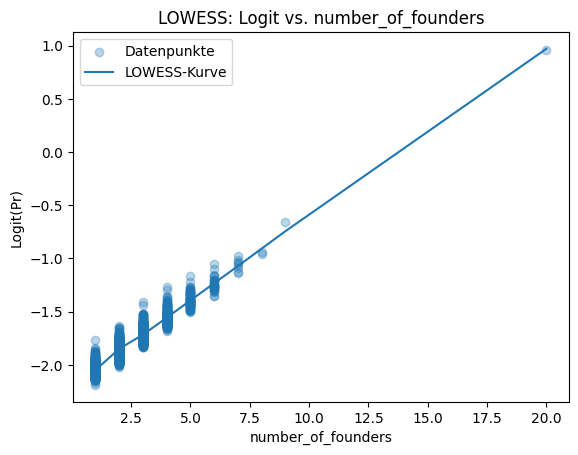

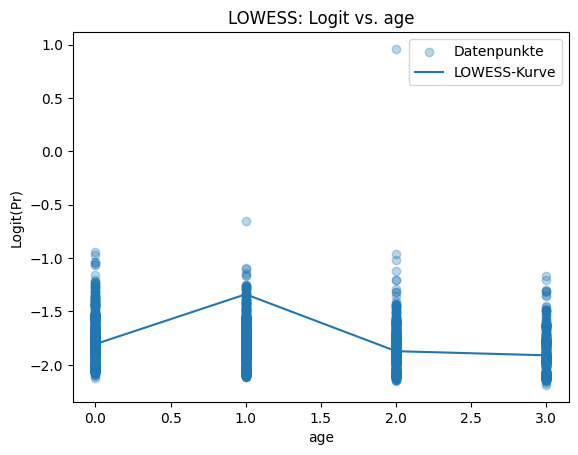

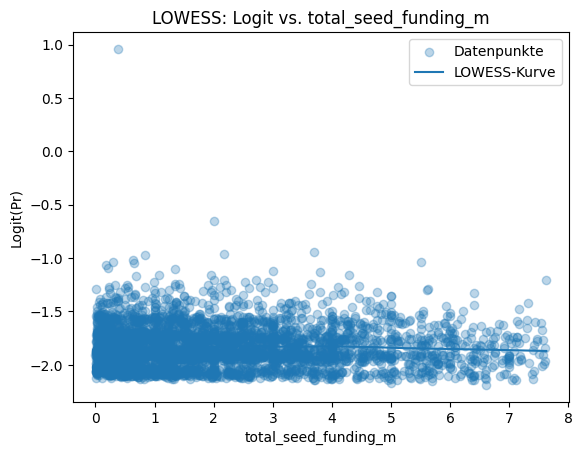

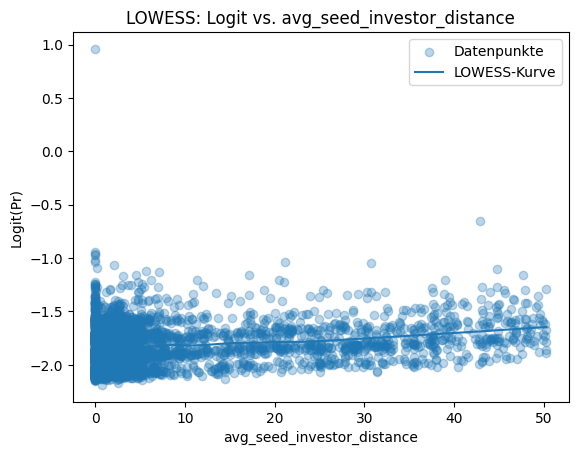

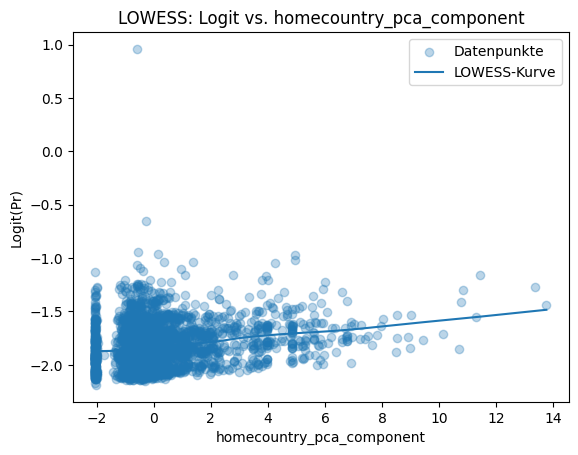

In [701]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

df = data.copy()

# Stelle sicher, dass 'success' als 0/1 kodiert ist, z.B.:
# data['success'] = data['success'].map({False:0, True:1})
df['exit_binary'] = df['exit_binary'].astype(int)
# Liste der kontinuierlichen Prädiktoren
continuous_vars = [
    'number_of_founders',
    'age',
    'total_seed_funding_m',
    'avg_seed_investor_distance',
    'homecountry_pca_component'
]

# 1) Box‐Tidwell‐Ansatz: Prädiktor × log(Prädiktor)
for var in continuous_vars:
    df[f'log_{var}'] = np.log(df[var] + 1e-6)
    df[f'{var}_x_log_{var}'] = df[var] * df[f'log_{var}']

# Logistisches Modell mit allen Interaktionstermen
formula_bt = 'exit_binary ~ ' + ' + '.join(
    [f"{var} + {var}_x_log_{var}" for var in continuous_vars]
)
model_bt = smf.logit(formula_bt, data=df).fit(disp=False)
print(model_bt.summary())

# 2) LOWESS‐Diagnose für jeden Prädiktor
# Basis‐Modell ohne die Log‐Interaktionen
formula_base = 'exit_binary ~ ' + ' + '.join(continuous_vars)
model_base = smf.logit(formula_base, data=df).fit(disp=False)

# Gefittete Wahrscheinlichkeiten und Logits berechnen
df['fitted'] = model_base.predict()
df['logit']  = np.log(df['fitted'] / (1 - df['fitted']))

# Lowess‐Plots erstellen
for var in continuous_vars:
    smoothed = lowess(
        endog=df['logit'],
        exog=df[var],
        frac=0.3,
        it=0
    )
    plt.figure()
    plt.scatter(df[var], df['logit'], alpha=0.3, label='Datenpunkte')
    plt.plot(smoothed[:, 0], smoothed[:, 1], label='LOWESS-Kurve')
    plt.xlabel(var)
    plt.ylabel('Logit(Pr)')
    plt.title(f'LOWESS: Logit vs. {var}')
    plt.legend()
    plt.show()

Optimization terminated successfully.
         Current function value: 0.393331
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            exit_binary   No. Observations:                 4254
Model:                          Logit   Df Residuals:                     4246
Method:                           MLE   Df Model:                            7
Date:                Mon, 23 Jun 2025   Pseudo R-squ.:                 0.01984
Time:                        09:13:20   Log-Likelihood:                -1673.2
converged:                       True   LL-Null:                       -1707.1
Covariance Type:            nonrobust   LLR p-value:                 4.201e-12
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------
Inte

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


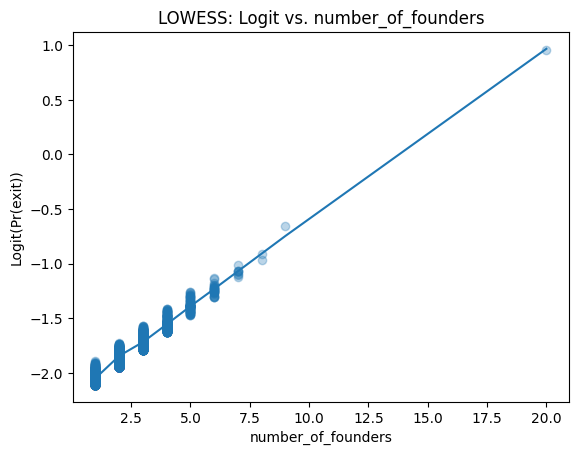

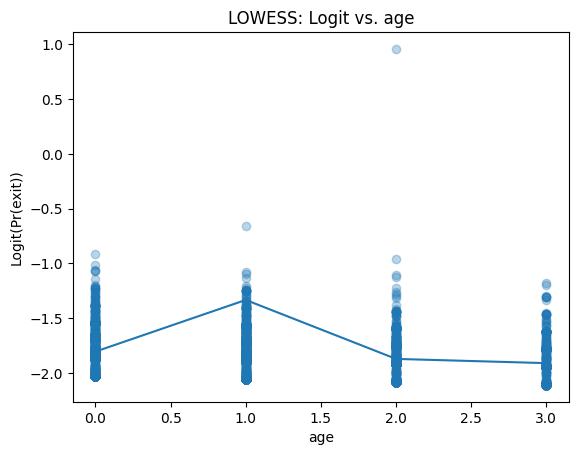

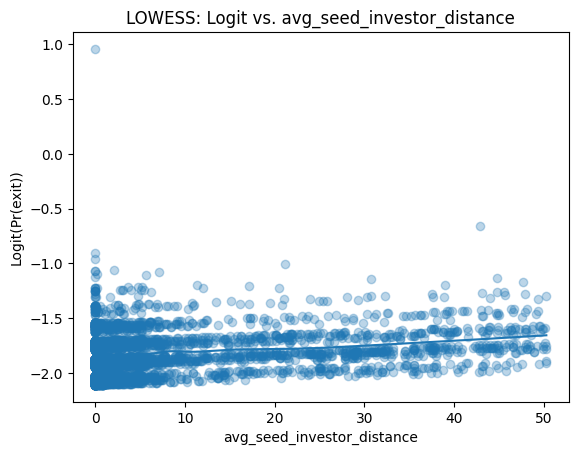

In [702]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy import bs
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

df = data.copy()

# --- 1) DataFrame vorbereiten ---
# data = pd.read_csv('deine_daten.csv')
df['exit_binary'] = df['exit_binary'].astype(int)

# 2) Funding-Variable standardisieren
df['std_fund'] = (
    df['total_seed_funding_m'] - df['total_seed_funding_m'].mean()
) / df['total_seed_funding_m'].std()

# 3) Knot definieren (z.B. Median)
knot = [df['std_fund'].median()]

# 4) Logit mit B-Splines und genau einem inneren Knoten
formula_spl = """
exit_binary ~
    number_of_founders +
    age +
    avg_seed_investor_distance +
    bs(std_fund, knots=knot, degree=3, include_intercept=False)
"""
model_spl = smf.logit(formula_spl, data=df).fit()
print(model_spl.summary())

# 5) Box–Tidwell für die übrigen Variablen
bt_vars = ['number_of_founders', 'age', 'avg_seed_investor_distance']
for var in bt_vars:
    df[f'log_{var}'] = np.log(df[var] + 1e-6)
    df[f'{var}_x_log_{var}'] = df[var] * df[f'log_{var}']

formula_bt2 = (
    "exit_binary ~ "
    + " + ".join(f"{v} + {v}_x_log_{v}" for v in bt_vars)
    + " + bs(std_fund, knots=knot, degree=3, include_intercept=False)"
)
model_bt2 = smf.logit(formula_bt2, data=df).fit(disp=False)
print(model_bt2.summary())

# 6) LOWESS-Plots zur visuellen Kontrolle der linearen Variablen
formula_base = 'exit_binary ~ ' + ' + '.join(bt_vars)
model_base = smf.logit(formula_base, data=df).fit(disp=False)
df['fitted'] = model_base.predict()
df['logit']  = np.log(df['fitted'] / (1 - df['fitted']))

for var in bt_vars:
    sm = lowess(df['logit'], df[var], frac=0.3, it=0)
    plt.figure()
    plt.scatter(df[var], df['logit'], alpha=0.3)
    plt.plot(sm[:, 0], sm[:, 1])
    plt.title(f'LOWESS: Logit vs. {var}')
    plt.xlabel(var)
    plt.ylabel('Logit(Pr(exit))')
    plt.show()

In [703]:
data

,company_id,organization_name,founded_year,headquarters_country,number_of_founders,age,hub_binary,b2b_binary,total_seed_funding_m,number_seed_rounds,...,closeness_homecountry,eigenvector_homecountry,success,exit_binary,funding_success,years_to_exit,seed_investors_all_same_country,seed_investors_all_same_city,global_pca_component,homecountry_pca_component
0,16735,Quick TV,2007,United Kingdom,2.0,0,False,False,2.337580,2,...,0.303639,1.207098e-03,False,False,False,NaN,True,True,0.045707,-0.316307
3,1297,Talentsoft,2007,France,3.0,2,True,True,2.343320,1,...,0.318834,1.785179e-03,True,True,True,14.0,True,True,-0.429935,-0.361783
16,16682,Sonik Sports,2007,United Kingdom,1.0,3,False,False,0.694767,1,...,0.303639,1.207098e-03,False,False,False,NaN,True,False,0.045707,-0.316307
19,16673,Videoplaza,2007,United Kingdom,3.0,1,True,True,0.662204,1,...,0.278280,2.241145e-05,True,True,False,7.0,True,False,-0.574210,-0.860964
21,16902,Deminos,2007,United Kingdom,2.0,3,True,True,0.274983,2,...,0.303639,1.207098e-03,False,False,False,NaN,True,False,0.045707,-0.316307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11059,9583,Reverion,2022,Germany,5.0,0,False,True,7.312125,1,...,0.332879,2.176031e-04,True,False,True,NaN,False,False,-0.178766,-0.474921
11060,9582,C1 Green Chemicals,2022,Germany,2.0,0,True,True,5.487553,1,...,0.346535,2.163292e-04,True,False,True,NaN,True,True,-0.271518,-0.363704
11067,18386,Supernova,2022,United Kingdom,1.0,0,True,False,2.540386,1,...,0.254871,2.018608e-05,False,False,False,NaN,True,True,-1.089962,-0.959082
11093,9665,heycare (former heynanny),2022,Germany,2.0,0,True,False,1.752883,2,...,0.247144,1.433049e-07,False,False,False,NaN,True,False,-1.023104,-0.980951


                            OLS Regression Results                            
Dep. Variable:      log_years_to_exit   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.485
Date:                Mon, 23 Jun 2025   Prob (F-statistic):           0.000131
Time:                        09:13:21   Log-Likelihood:                -399.99
No. Observations:                 587   AIC:                             850.0
Df Residuals:                     562   BIC:                             959.4
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

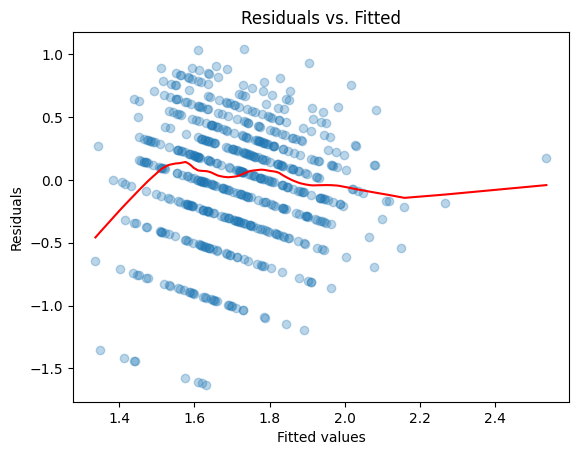

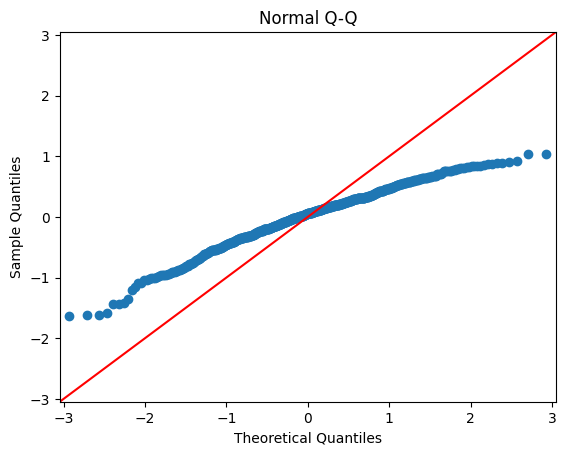

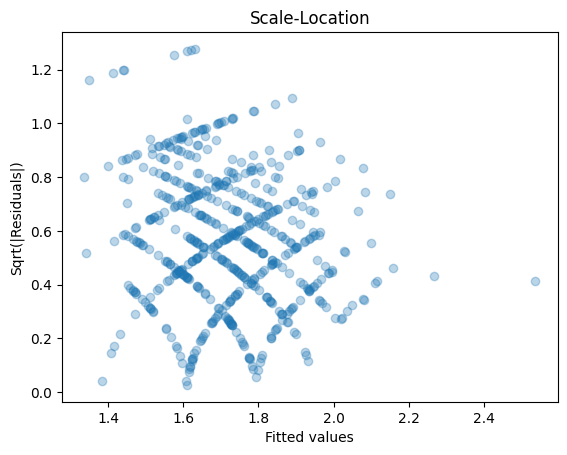

                                   Variable        VIF
0                                 Intercept  63.558313
1           headquarters_country[T.Germany]   1.646829
2             headquarters_country[T.Italy]   1.368317
3            headquarters_country[T.Poland]   1.085108
4             headquarters_country[T.Spain]   1.366297
5       headquarters_country[T.Switzerland]   1.256985
6   headquarters_country[T.The Netherlands]   1.244414
7    headquarters_country[T.United Kingdom]   1.908328
8                        hub_binary[T.True]   1.178009
9                        b2b_binary[T.True]   1.352876
10                           energy[T.True]   1.668477
11                        materials[T.True]   1.091353
12                      industrials[T.True]   1.100037
13           consumer_discretionary[T.True]   1.296000
14                 consumer_staples[T.True]   1.141373
15                      health_care[T.True]   1.142948
16                       financials[T.True]   1.150652
17        

In [704]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt


data['log_years_to_exit'] = np.log(data['years_to_exit'])

# 2) Kontinuierliche Zielvariable definieren
dv = 'log_years_to_exit'

# 3) Liste der Prädiktoren
predictors = [
  "closeness_global",
  "number_of_founders",
  "age",
  "headquarters_country", "hub_binary", "b2b_binary",
  "energy", "materials", "industrials", "consumer_discretionary",
  "consumer_staples", "health_care", "financials",
  "information_technology", "communication_services",
  "utilities", "real_estate", "other"
]

# 4) Lineares Modell (OLS) fitten
formula = dv + ' ~ ' + ' + '.join(predictors)
model_linear = smf.ols(formula, data=data).fit()
print(model_linear.summary())

# 5) Residual-Diagnostik

# Residuen und gefittete Werte
resid = model_linear.resid
fitted = model_linear.fittedvalues

# 5a) Residuals vs. Fitted (Linearity & Homoskedastizität)
smoothed = lowess(resid, fitted, frac=0.3)
plt.figure()
plt.scatter(fitted, resid, alpha=0.3)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

# 5b) Q-Q-Plot (Normalität der Residuen)
sm.qqplot(resid, line='45')
plt.title('Normal Q-Q')
plt.show()

# 5c) Scale-Location (Homoskedastizität)
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.3)
plt.xlabel('Fitted values')
plt.ylabel('Sqrt(|Residuals|)')
plt.title('Scale-Location')
plt.show()

# 6) Multikollinearitäts-Check (VIF)
X = model_linear.model.exog
vif = pd.DataFrame({
    'Variable': model_linear.model.exog_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif)

Add dummy for network

In [705]:
data

,company_id,organization_name,founded_year,headquarters_country,number_of_founders,age,hub_binary,b2b_binary,total_seed_funding_m,number_seed_rounds,...,eigenvector_homecountry,success,exit_binary,funding_success,years_to_exit,seed_investors_all_same_country,seed_investors_all_same_city,global_pca_component,homecountry_pca_component,log_years_to_exit
0,16735,Quick TV,2007,United Kingdom,2.0,0,False,False,2.337580,2,...,1.207098e-03,False,False,False,NaN,True,True,0.045707,-0.316307,NaN
3,1297,Talentsoft,2007,France,3.0,2,True,True,2.343320,1,...,1.785179e-03,True,True,True,14.0,True,True,-0.429935,-0.361783,2.639057
16,16682,Sonik Sports,2007,United Kingdom,1.0,3,False,False,0.694767,1,...,1.207098e-03,False,False,False,NaN,True,False,0.045707,-0.316307,NaN
19,16673,Videoplaza,2007,United Kingdom,3.0,1,True,True,0.662204,1,...,2.241145e-05,True,True,False,7.0,True,False,-0.574210,-0.860964,1.945910
21,16902,Deminos,2007,United Kingdom,2.0,3,True,True,0.274983,2,...,1.207098e-03,False,False,False,NaN,True,False,0.045707,-0.316307,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11059,9583,Reverion,2022,Germany,5.0,0,False,True,7.312125,1,...,2.176031e-04,True,False,True,NaN,False,False,-0.178766,-0.474921,NaN
11060,9582,C1 Green Chemicals,2022,Germany,2.0,0,True,True,5.487553,1,...,2.163292e-04,True,False,True,NaN,True,True,-0.271518,-0.363704,NaN
11067,18386,Supernova,2022,United Kingdom,1.0,0,True,False,2.540386,1,...,2.018608e-05,False,False,False,NaN,True,True,-1.089962,-0.959082,NaN
11093,9665,heycare (former heynanny),2022,Germany,2.0,0,True,False,1.752883,2,...,1.433049e-07,False,False,False,NaN,True,False,-1.023104,-0.980951,NaN


In [706]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

closeness_homecountry    0
dtype: int64
Anzahl Null-Werte: 211 (5.0%)


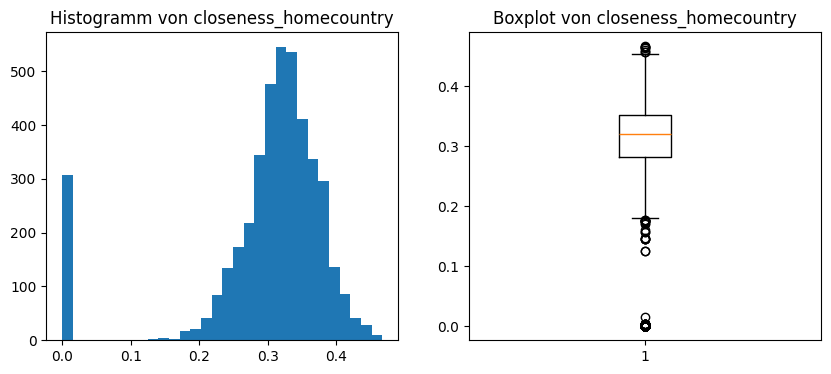

In [707]:
df = data.copy()
# 1.1 fehlende Werte
print(df[['closeness_homecountry']].isna().sum())

# 1.2 Null-Massen
n_zero = (df['closeness_homecountry'] == 0).sum()
print(f"Anzahl Null-Werte: {n_zero} ({n_zero/len(df):.1%})")

# 1.3 Histogramm & Boxplot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['closeness_homecountry'], bins=30)
plt.title("Histogramm von closeness_homecountry")
plt.subplot(1,2,2)
plt.boxplot(df['closeness_homecountry'])
plt.title("Boxplot von closeness_homecountry")
plt.show()

In [708]:
data['closeness_homecountry_zero'] = (data['closeness_homecountry'] == 0).astype(int)
data['closeness_homecountry_positive'] = data['closeness_homecountry'].clip(lower=0)

data['closeness_global_zero'] = (data['closeness_global'] == 0).astype(int)
data['closeness_global_positive'] = data['closeness_global'].clip(lower=0)

In [709]:
data

,company_id,organization_name,founded_year,headquarters_country,number_of_founders,age,hub_binary,b2b_binary,total_seed_funding_m,number_seed_rounds,...,years_to_exit,seed_investors_all_same_country,seed_investors_all_same_city,global_pca_component,homecountry_pca_component,log_years_to_exit,closeness_homecountry_zero,closeness_homecountry_positive,closeness_global_zero,closeness_global_positive
0,16735,Quick TV,2007,United Kingdom,2.0,0,False,False,2.337580,2,...,NaN,True,True,0.045707,-0.316307,NaN,0,0.303639,0,0.300753
3,1297,Talentsoft,2007,France,3.0,2,True,True,2.343320,1,...,14.0,True,True,-0.429935,-0.361783,2.639057,0,0.318834,0,0.312011
16,16682,Sonik Sports,2007,United Kingdom,1.0,3,False,False,0.694767,1,...,NaN,True,False,0.045707,-0.316307,NaN,0,0.303639,0,0.300753
19,16673,Videoplaza,2007,United Kingdom,3.0,1,True,True,0.662204,1,...,7.0,True,False,-0.574210,-0.860964,1.945910,0,0.278280,0,0.308886
21,16902,Deminos,2007,United Kingdom,2.0,3,True,True,0.274983,2,...,NaN,True,False,0.045707,-0.316307,NaN,0,0.303639,0,0.300753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11059,9583,Reverion,2022,Germany,5.0,0,False,True,7.312125,1,...,NaN,False,False,-0.178766,-0.474921,NaN,0,0.332879,0,0.338985
11060,9582,C1 Green Chemicals,2022,Germany,2.0,0,True,True,5.487553,1,...,NaN,True,True,-0.271518,-0.363704,NaN,0,0.346535,0,0.331711
11067,18386,Supernova,2022,United Kingdom,1.0,0,True,False,2.540386,1,...,NaN,True,True,-1.089962,-0.959082,NaN,0,0.254871,0,0.264620
11093,9665,heycare (former heynanny),2022,Germany,2.0,0,True,False,1.752883,2,...,NaN,True,False,-1.023104,-0.980951,NaN,0,0.247144,0,0.272791


In [710]:
data.to_csv('data/sets-for-r/regression_data.csv', index=False)

In [713]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the variables for correlation analysis
selected_variables = ['global_pca_component', 'number_seed_rounds']

# Calculate the correlation matrix
correlation_matrix = data[selected_variables].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Calculate VIF for the selected variables
X = data[selected_variables].assign(Intercept=1)  # Add intercept for VIF calculation
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Display VIF values
print("\nVariance Inflation Factor (VIF):")
print(vif_data)

Correlation Matrix:
                      global_pca_component  number_seed_rounds
global_pca_component              1.000000            0.323878
number_seed_rounds                0.323878            1.000000

Variance Inflation Factor (VIF):
               Variable       VIF
0  global_pca_component  1.117190
1    number_seed_rounds  1.117190
2             Intercept  6.906531
